# Checkpoint 1 

Neste checkpoint, o objetivo é testar dois modelos para classificação de textos:
1. um baseline de regressão logística;
2. uma Deep Neural Network (DNN).

## Imports

In [23]:
import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from activation import ReLUActivation, SigmoidActivation
from layers import DenseLayer, DropoutLayer
from losses import BinaryCrossEntropy
from neuralnetwork import NeuralNetwork

## Dataset

In [24]:
df = pd.read_csv("DatasetFinal/dataset_final.csv")
df.head()

,Text,source_name,source_code
0,By . Daily Mail Reporter . A former North Kore...,human,0
1,"i dont like working in teams, its too much hassle",human,0
2,We summarize a theoretical framework based o...,human,0
3,13 Disastrous Vending Machine FAILS (PHOTOS)\n...,meta,3
4,"However , net sales in 2010 are seen to have g...",human,0


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15555 entries, 0 to 15554
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Text         15555 non-null  str  
 1   source_name  15555 non-null  str  
 2   source_code  15555 non-null  int64
dtypes: int64(1), str(2)
memory usage: 24.8 MB


In [26]:
df["source_name"].value_counts()

source_name
human      7650
openai     2435
google     1900
meta       1838
mistral    1732
Name: count, dtype: int64

## Análise inicial do dataset

O dataset contém textos classificados por origem.  
As classes disponíveis são:

- human
- openai
- google
- meta
- mistral

Para esta primeira abordagem, vamos converter o problema para classificação binária:
- **human = 0**
- **qualquer modelo LLM = 1**

In [27]:
df["binary_label"] = (df["source_name"] != "human").astype(int)
df[["source_name", "binary_label"]].head()

df["binary_label"].value_counts()

#df["binary_label"].value_counts(normalize=True) * 100 #PERCENTAGEM

binary_label
1    7905
0    7650
Name: count, dtype: int64

## Visualização Gráfica

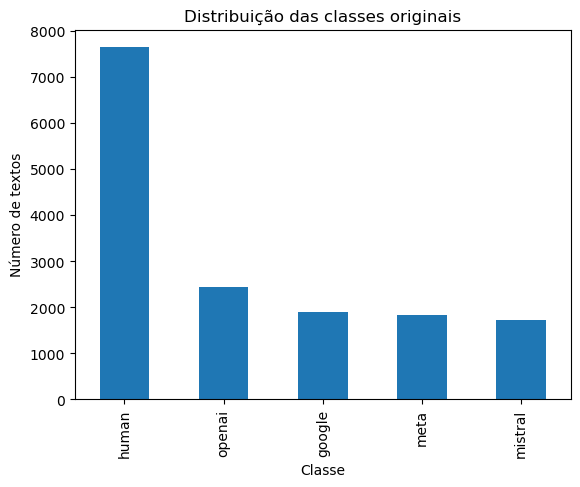

In [28]:
df["source_name"].value_counts().plot(kind="bar")
plt.title("Distribuição das classes originais")
plt.xlabel("Classe")
plt.ylabel("Número de textos")
plt.show()

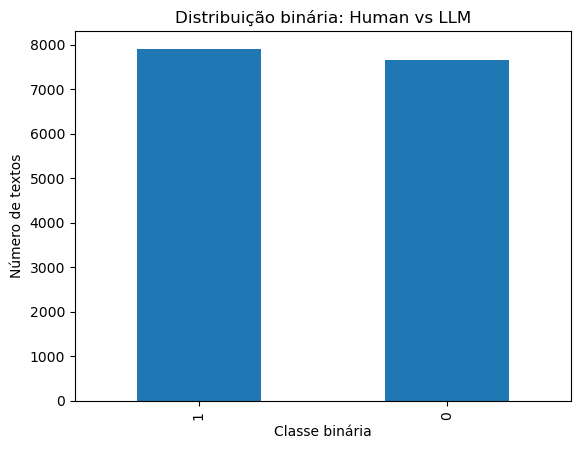

In [29]:
df["binary_label"].value_counts().plot(kind="bar")
plt.title("Distribuição binária: Human vs LLM")
plt.xlabel("Classe binária")
plt.ylabel("Número de textos")
plt.show()

## Pré-Processamento

Os textos são extraídos para uma variável de entrada e os rótulos binários para uma variável alvo. A partir daqui, os dados serão divididos em treino e teste, e posteriormente convertidos em representações numéricas.

In [30]:
X_text = df["Text"].astype(str).values
y = df["binary_label"].values

Separação estratificada simples, proporção entre as classes no conjunto de treino e no conjunto de teste.

In [31]:
def train_test_split_manual(X, y, test_size=0.2, random_state=42):
    rng = np.random.default_rng(random_state)

    class_0_idx = np.where(y == 0)[0]
    class_1_idx = np.where(y == 1)[0]

    rng.shuffle(class_0_idx)
    rng.shuffle(class_1_idx)

    n0_test = int(len(class_0_idx) * test_size)
    n1_test = int(len(class_1_idx) * test_size)

    test_idx = np.concatenate([class_0_idx[:n0_test], class_1_idx[:n1_test]])
    train_idx = np.concatenate([class_0_idx[n0_test:], class_1_idx[n1_test:]])

    rng.shuffle(train_idx)
    rng.shuffle(test_idx)

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train_text, X_test_text, y_train, y_test = train_test_split_manual(
    X_text, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

Train size: 12444
Test size: 3111


1. tokenização e normalização do texto;
2. remoção de stopwords;
3. construção do vocabulário a partir do conjunto de treino;
4. cálculo do IDF para cada termo;
5. vetorização TF-IDF dos textos de treino e teste.

In [32]:
STOPWORDS = {
    "the", "a", "an", "and", "or", "of", "to", "in", "on", "at", "for", "with",
    "is", "are", "was", "were", "be", "been", "being", "this", "that", "these",
    "those", "it", "its", "as", "by", "from", "but", "about", "into", "than",
    "then", "so", "such", "if", "their", "there", "they", "them", "he", "she",
    "you", "your", "we", "our", "i", "my", "me", "his", "her", "what", "which",
    "who", "whom", "can", "could", "should", "would", "do", "does", "did", "have",
    "has", "had", "not", "no", "yes", "will", "just"
}

def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"\b[a-zA-ZÀ-ÿ]{2,}\b", text)
    return [tok for tok in tokens if tok not in STOPWORDS]

def build_vocabulary(texts, max_features=5000):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    most_common = counter.most_common(max_features)
    vocab = {word: idx for idx, (word, _) in enumerate(most_common)}
    return vocab

def compute_idf(tokenized_texts, vocab):
    n_docs = len(tokenized_texts)
    df_counts = np.zeros(len(vocab), dtype=np.float64)

    for tokens in tokenized_texts:
        unique_tokens = set(tok for tok in tokens if tok in vocab)
        for tok in unique_tokens:
            df_counts[vocab[tok]] += 1

    idf = np.log((1 + n_docs) / (1 + df_counts)) + 1
    return idf

def vectorize_tfidf(texts, vocab, idf):
    X = np.zeros((len(texts), len(vocab)), dtype=np.float64)

    for i, text in enumerate(texts):
        tokens = [tok for tok in tokenize(text) if tok in vocab]
        if not tokens:
            continue

        counts = Counter(tokens)
        total_terms = len(tokens)

        for tok, count in counts.items():
            j = vocab[tok]
            tf = count / total_terms
            X[i, j] = tf * idf[j]

    return X

def l2_normalize_rows(X, eps=1e-12):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / (norms + eps)

vocab = build_vocabulary(X_train_text, max_features=5000)

train_tokens = [tokenize(text) for text in X_train_text]
idf = compute_idf(train_tokens, vocab)

X_train = vectorize_tfidf(X_train_text, vocab, idf)
X_test = vectorize_tfidf(X_test_text, vocab, idf)

X_train = l2_normalize_rows(X_train)
X_test = l2_normalize_rows(X_test)

print("Vocabulary size:", len(vocab))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Vocabulary size: 5000
X_train shape: (12444, 5000)
X_test shape: (3111, 5000)


In [33]:
# ajuste ao neuralnetwork.py

class SimpleDataset:
    def __init__(self, X, y):
        self.X = X
        self.y = y

train_data = SimpleDataset(X_train, y_train)
test_data = SimpleDataset(X_test, y_test)

# Baseline: Regressão Logística

Binary Cross-Entropy como função de perda.

In [34]:
baseline_model = NeuralNetwork(
    epochs=80,
    batch_size=64,
    learning_rate=0.001,
    momentum=0.9,
    verbose=True,
    loss=BinaryCrossEntropy,
    metric=None,
    early_stopping=True,
    early_stopping_patience=8
)

baseline_model.add(DenseLayer(1, input_shape=(X_train.shape[1],), initialization="xavier"))
baseline_model.add(SigmoidActivation())

In [35]:
baseline_model.fit(train_data)

Epoch 1/80 - loss: 0.6930
Epoch 2/80 - loss: 0.6928
Epoch 3/80 - loss: 0.6927
Epoch 4/80 - loss: 0.6925
Epoch 5/80 - loss: 0.6924
Epoch 6/80 - loss: 0.6922
Epoch 7/80 - loss: 0.6921
Epoch 8/80 - loss: 0.6919
Epoch 9/80 - loss: 0.6918
Epoch 10/80 - loss: 0.6916
Epoch 11/80 - loss: 0.6914
Epoch 12/80 - loss: 0.6913
Epoch 13/80 - loss: 0.6911
Epoch 14/80 - loss: 0.6910
Epoch 15/80 - loss: 0.6908
Epoch 16/80 - loss: 0.6907
Epoch 17/80 - loss: 0.6905
Epoch 18/80 - loss: 0.6904
Epoch 19/80 - loss: 0.6902
Epoch 20/80 - loss: 0.6901
Epoch 21/80 - loss: 0.6899
Epoch 22/80 - loss: 0.6898
Epoch 23/80 - loss: 0.6897
Epoch 24/80 - loss: 0.6895
Epoch 25/80 - loss: 0.6894
Epoch 26/80 - loss: 0.6892
Epoch 27/80 - loss: 0.6891
Epoch 28/80 - loss: 0.6889
Epoch 29/80 - loss: 0.6888
Epoch 30/80 - loss: 0.6886
Epoch 31/80 - loss: 0.6885
Epoch 32/80 - loss: 0.6883
Epoch 33/80 - loss: 0.6882
Epoch 34/80 - loss: 0.6880
Epoch 35/80 - loss: 0.6879
Epoch 36/80 - loss: 0.6877
Epoch 37/80 - loss: 0.6876
Epoch 38/8

In [36]:
y_pred_prob_baseline = baseline_model.predict(test_data)
y_pred_baseline = (y_pred_prob_baseline >= 0.5).astype(int).flatten()

In [37]:
def accuracy_score_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp],
                     [fn, tp]])

def precision_score_manual(y_true, y_pred):
    cm = confusion_matrix_manual(y_true, y_pred)
    tp = cm[1, 1]
    fp = cm[0, 1]
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_score_manual(y_true, y_pred):
    cm = confusion_matrix_manual(y_true, y_pred)
    tp = cm[1, 1]
    fn = cm[1, 0]
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_score_manual(y_true, y_pred):
    precision = precision_score_manual(y_true, y_pred)
    recall = recall_score_manual(y_true, y_pred)
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

def classification_report_manual(y_true, y_pred):
    precision_0 = precision_score_manual(1 - y_true, 1 - y_pred)
    recall_0 = recall_score_manual(1 - y_true, 1 - y_pred)
    f1_0 = f1_score_manual(1 - y_true, 1 - y_pred)
    support_0 = np.sum(y_true == 0)

    precision_1 = precision_score_manual(y_true, y_pred)
    recall_1 = recall_score_manual(y_true, y_pred)
    f1_1 = f1_score_manual(y_true, y_pred)
    support_1 = np.sum(y_true == 1)

    print("Classe\tPrecision\tRecall\t\tF1-score\tSupport")
    print(f"human\t{precision_0:.4f}\t\t{recall_0:.4f}\t\t{f1_0:.4f}\t\t{support_0}")
    print(f"LLM\t{precision_1:.4f}\t\t{recall_1:.4f}\t\t{f1_1:.4f}\t\t{support_1}")

baseline_accuracy = accuracy_score_manual(y_test, y_pred_baseline)
baseline_precision = precision_score_manual(y_test, y_pred_baseline)
baseline_recall = recall_score_manual(y_test, y_pred_baseline)
baseline_f1 = f1_score_manual(y_test, y_pred_baseline)

print("Accuracy:", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall:", baseline_recall)
print("F1-score:", baseline_f1)

Accuracy: 0.6772741883638701
Precision: 0.6134486826582777
Recall: 0.9867172675521821
F1-score: 0.7565470417070805


## DNN(NumPy)

- camada densa intermédia;
- ativação ReLU;
- dropout como técnica de regularização;
- camada de saída com ativação sigmoide.

In [38]:
model = NeuralNetwork(
    epochs=100,
    batch_size=64,
    learning_rate=0.001,
    momentum=0.9,
    verbose=True,
    loss=BinaryCrossEntropy,
    metric=None,
    early_stopping=True,
    early_stopping_patience=10
)

model.add(DenseLayer(64, input_shape=(X_train.shape[1],), l2_lambda=1e-4, initialization="he"))
model.add(ReLUActivation())
model.add(DropoutLayer(0.2))
model.add(DenseLayer(1, l2_lambda=1e-4, initialization="xavier"))
model.add(SigmoidActivation())

In [39]:
model.fit(train_data)

Epoch 1/100 - loss: 0.6932
Epoch 2/100 - loss: 0.6932
Epoch 3/100 - loss: 0.6931
Epoch 4/100 - loss: 0.6929
Epoch 5/100 - loss: 0.6928
Epoch 6/100 - loss: 0.6926
Epoch 7/100 - loss: 0.6925
Epoch 8/100 - loss: 0.6925
Epoch 9/100 - loss: 0.6923
Epoch 10/100 - loss: 0.6922
Epoch 11/100 - loss: 0.6921
Epoch 12/100 - loss: 0.6920
Epoch 13/100 - loss: 0.6919
Epoch 14/100 - loss: 0.6918
Epoch 15/100 - loss: 0.6917
Epoch 16/100 - loss: 0.6916
Epoch 17/100 - loss: 0.6915
Epoch 18/100 - loss: 0.6913
Epoch 19/100 - loss: 0.6911
Epoch 20/100 - loss: 0.6911
Epoch 21/100 - loss: 0.6909
Epoch 22/100 - loss: 0.6908
Epoch 23/100 - loss: 0.6908
Epoch 24/100 - loss: 0.6906
Epoch 25/100 - loss: 0.6905
Epoch 26/100 - loss: 0.6903
Epoch 27/100 - loss: 0.6903
Epoch 28/100 - loss: 0.6902
Epoch 29/100 - loss: 0.6900
Epoch 30/100 - loss: 0.6900
Epoch 31/100 - loss: 0.6896
Epoch 32/100 - loss: 0.6896
Epoch 33/100 - loss: 0.6895
Epoch 34/100 - loss: 0.6894
Epoch 35/100 - loss: 0.6892
Epoch 36/100 - loss: 0.6891
E

In [40]:
y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print(y_pred_prob[:10])
print(y_pred[:10])

[[0.52334814]
 [0.49859863]
 [0.51092246]
 [0.51277732]
 [0.50952018]
 [0.51107169]
 [0.50600506]
 [0.50169168]
 [0.5205455 ]
 [0.51395425]]
[1 0 1 1 1 1 1 1 1 1]


In [41]:
dnn_accuracy = accuracy_score_manual(y_test, y_pred)
dnn_precision = precision_score_manual(y_test, y_pred)
dnn_recall = recall_score_manual(y_test, y_pred)
dnn_f1 = f1_score_manual(y_test, y_pred)

print("Accuracy:", dnn_accuracy)
print("Precision:", dnn_precision)
print("Recall:", dnn_recall)
print("F1-score:", dnn_f1)

print("\nClassification report:")
classification_report_manual(y_test, y_pred)

cm = confusion_matrix_manual(y_test, y_pred)
print("\nConfusion matrix:")
print(cm)

Accuracy: 0.718097074895532
Precision: 0.6474036850921273
Recall: 0.9778621125869703
F1-score: 0.7790375409423029

Classification report:
Classe	Precision	Recall		F1-score	Support
human	0.9516		0.4497		0.6107		1530
LLM	0.6474		0.9779		0.7790		1581

Confusion matrix:
[[ 688  842]
 [  35 1546]]


In [42]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression (NumPy)", "DNN (NumPy)"],
    "Accuracy": [baseline_accuracy, dnn_accuracy],
    "Precision": [baseline_precision, dnn_precision],
    "Recall": [baseline_recall, dnn_recall],
    "F1-score": [baseline_f1, dnn_f1]
})
comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression (NumPy),0.677274,0.613449,0.986717,0.756547
1,DNN (NumPy),0.718097,0.647404,0.977862,0.779038


O DNN atingiu o melhor desempenho global, com um F1-score de 0.77, em comparação com o 0.71 da baseline de regressão logistica.

Ambos os modelos atingiram um recall alto na deteção de texto gerado por IA. O DNN aumentou a precision, fruto de um melhor equilíbrio entre falsos positivos e falsos negativos.

## Curvas de Treino

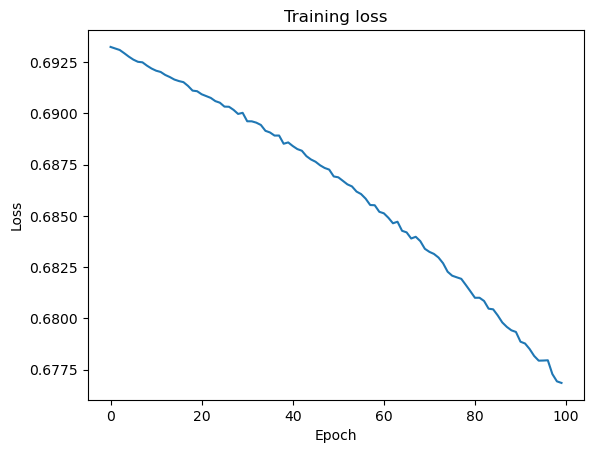

In [43]:
plt.plot(model.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()